In [16]:
#### start interactive session before nay heavy lifting
import os
# os.system("interact -q gpu -g 1 -m 32g -t 24:00:00")


In [17]:
import numpy as np
from particleloader import load
import matplotlib.pyplot as plt

In [18]:
### working directory
dir = "work"
#### load 1000 jets
N = 1000
#### X_pythia == pythia four vectors of jets
#### y_pythia == ids
X_pythia, y_pythia = load("qg_jets", N, cache_dir=dir)
X_herwig, y_herwig = load("qg_jets", N, cache_dir=dir, generator="herwig")

classes = ["gluon", "quark"]
colors = ["red", "blue"]

X_pythia contains (pt, $\eta$, $\phi$, PID) for the first 139 constituents of the jet.
X_herwig contains (pt, $\eta$, $\phi$, PID) for the first 136 constituents of the jet.
y_pythia and y_herwig contain an ID of whether the jet was quark (ID=1) or gluon(ID=0) initiated.

In [19]:
print(X_pythia.shape)
print(X_herwig.shape)
print(X_pythia[0,:,3])
print(X_pythia[0,1])
print(len(X_pythia[0].shape))
print(len(X_pythia[1]))
print(len(X_pythia[2]))

(1000, 139, 4)
(1000, 136, 4)
[  22.   22. -211. -321. -211.   22.   22.  211.  321. -211.   22.   22.
   22.   22.   22.   22.   22.   22.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.]
[ 0.16007638 -0.25560953  4.5502291  22.        ]
2
139
139


[ 0.26876914  0.16007638  1.14868731 ...  8.20837231 57.4797628
 25.90661654]
{'charged hadrons': [211, -211, 321, -321, 2212, -2212], 'photons': [22], 'neutral hadrons': [130, 310, 2112], 'electrons': [11, -11], 'muons': [13, -13]}


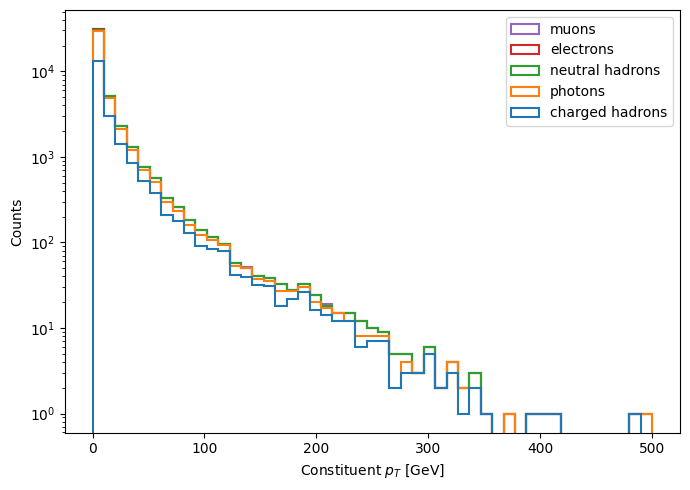

In [48]:
# plotting consituent pts
pid_map = {
    "charged hadrons": [211, -211, 321, -321, 2212, -2212],
    "photons": [22],
    "neutral hadrons": [130, 310, 2112],
    "electrons": [11, -11],
    "muons": [13, -13],
}
# flatten jets × constituents
pt  = X_pythia[..., 0].reshape(-1)
eta = X_pythia[..., 1].reshape(-1)
phi = X_pythia[..., 2].reshape(-1)
pid = X_pythia[..., 3].reshape(-1)
e = (X_pythia[:,:,0] * np.cosh(X_pythia[:,:,1])).reshape(-1)

# keep only filled constituents (pT > 0)
mask = pt > 0
pt  = pt[mask]
e = e[mask]
eta  = eta[mask]
phi  = phi[mask]
pid = pid[mask]
print(pt)
bins = np.linspace(0, 500, 50) 

plt.figure(figsize=(7, 5))
pts = []
print(pid_map)
for label, pdgs in pid_map.items():
    sel = np.isin(pid, pdgs)
    if np.any(sel):
        pts.append(pt[sel])

plt.hist(
    pts,
    bins=bins,
    histtype="step",
    linewidth=1.5,
    label=pid_map.keys(),
    stacked=True
)
        
plt.yscale("log")
plt.xlabel("Constituent $p_T$ [GeV]")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_601748/3017154203.py:17: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("Constituent $\eta$")


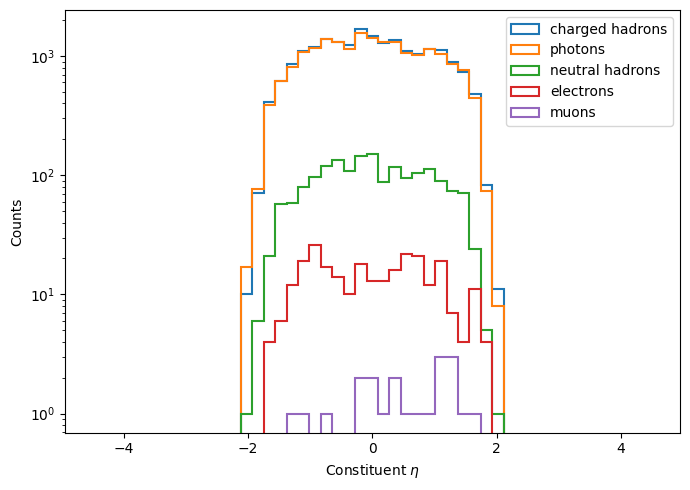

In [28]:
bins = np.linspace(-4.5, 4.5, 50)  # adjust as needed

plt.figure(figsize=(7, 5))

for label, pdgs in pid_map.items():
    sel = np.isin(pid, pdgs)
    if np.any(sel):
        plt.hist(
            eta[sel],
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label=label,
        )
        
plt.yscale("log")
plt.xlabel("Constituent $\eta$")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_601748/1021969437.py:17: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("Constituent $\phi$")


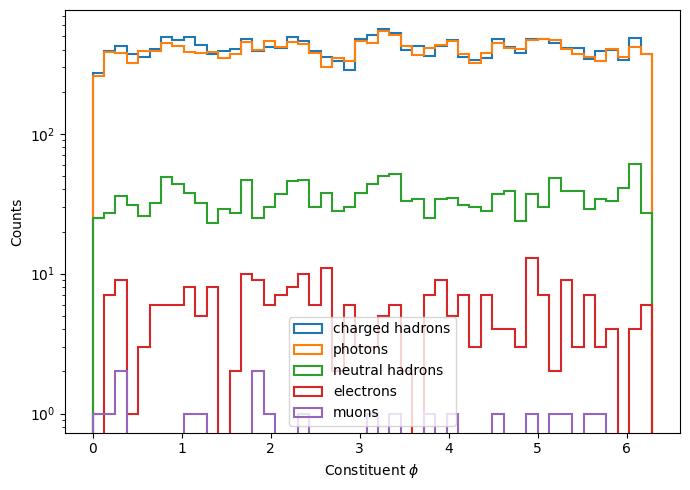

In [29]:
bins = np.linspace(0, 2*np.pi, 50)  # adjust as needed

plt.figure(figsize=(7, 5))

for label, pdgs in pid_map.items():
    sel = np.isin(pid, pdgs)
    if np.any(sel):
        plt.hist(
            phi[sel],
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label=label,
        )
        
plt.yscale("log")
plt.xlabel("Constituent $\phi$")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

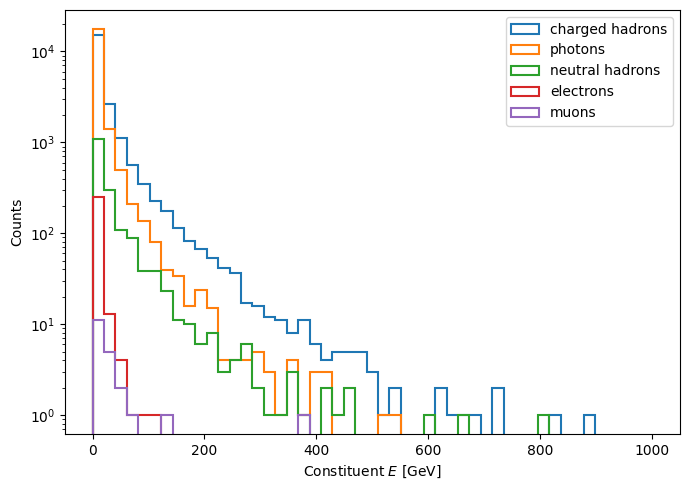

In [41]:
bins = np.linspace(0, 1000, 50)  # adjust as needed

plt.figure(figsize=(7, 5))

for label, pdgs in pid_map.items():
    sel = np.isin(pid, pdgs)
    if np.any(sel):
        plt.hist(
            e[sel],
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label=label,
            stacked=True
        )
        
plt.yscale("log")
plt.xlabel("Constituent $E$ [GeV]")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

[[7.7024505  0.20737717 1.14281773 ... 0.         0.         0.        ]
 [1.03690607 0.31846767 0.75744776 ... 0.         0.         0.        ]
 [3.29282555 4.33602474 3.58722365 ... 0.         0.         0.        ]
 ...
 [0.19463568 2.14259841 0.97380349 ... 0.         0.         0.        ]
 [0.35105377 0.49028251 0.05204733 ... 0.         0.         0.        ]
 [3.4948136  2.7170248  0.50707877 ... 0.         0.         0.        ]]


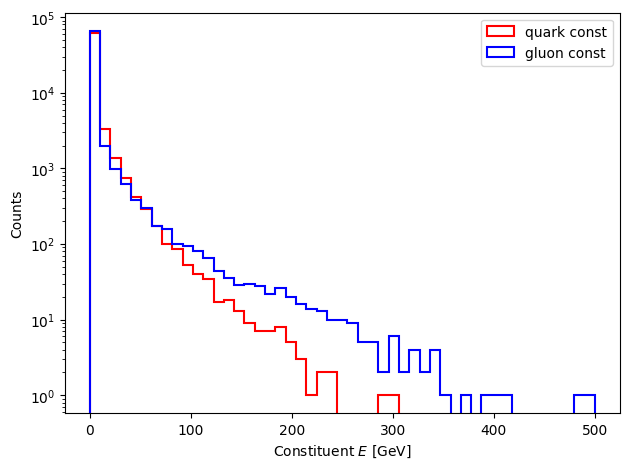

In [ ]:
### plot 
bins = np.linspace(0, 500, 50) 
y_pythia = np.array(y_pythia).astype(int)
mask = (y_pythia == 0)
pt  = X_pythia[..., 0]
print(pt[mask])
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="quark const",
            color="red"
        )
mask = (y_pythia != 0)
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="gluon const",
            color="blue"
        )
        

plt.xlabel("Constituent $pT$ [GeV]")
plt.ylabel("Counts")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

In [ ]:
### plot 
bins = np.linspace(0, 500, 50) 
y_pythia = np.array(y_pythia).astype(int)
mask = (y_pythia == 0)
pt  = X_pythia[..., 0]
print(pt[mask])
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="quark const",
            color="red"
        )
mask = (y_pythia != 0)
plt.hist(
            pt[mask].reshape(-1),
            bins=bins,
            histtype="step",
            linewidth=1.5,
            label="gluon const",
            color="blue"
        )
        

plt.xlabel("Constituent $pT$ [GeV]")
plt.ylabel("Counts")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()